In [1]:
from fenics import *
import numpy as np
import meshio
from dolfin import *
import matplotlib.pyplot as plt
import dolfin.common.plotting as fenicsplot 
#from vtkplotter.dolfin import plot
parameters = " matplotlib "
from PIL import Image

In [2]:
import warnings
warnings.filterwarnings("ignore")
import gmsh
gmsh.initialize()
import numpy as np

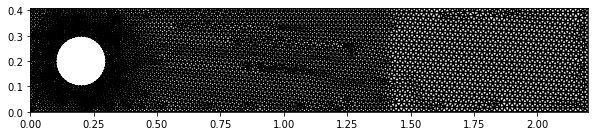

In [5]:
gmsh.model.add("DFG 2D")

import meshio
from dolfin import Mesh, XDMFFile

r = 0.1

# read gmsh mesh
msh = meshio.read(f"generated_mesh/mesh2D_r_{r}.msh")

# collect triangle cells
tri_cells = np.vstack(
    [cell.data for cell in msh.cells if cell.type == "triangle"]
)

# create triangle mesh
tri_mesh = meshio.Mesh(
    points=msh.points[:, :2],
    cells=[("triangle", tri_cells)]
)

# write xdmf
meshio.write(f"mesh2D_r_{r}.xdmf", tri_mesh)

# read in FEniCS
mesh_obj = Mesh()
with XDMFFile(f"mesh2D_r_{r}.xdmf") as infile:
    infile.read(mesh_obj)
    
    
from dolfin import *
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plot(mesh_obj, color = 'black')

plt.gca().set_aspect("equal")
plt.xlim(0, 2.2)
plt.ylim(0, 0.41)
plt.show()    

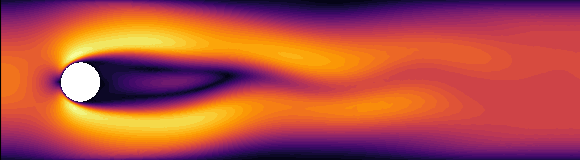

In [6]:
# Visualize flow images
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

r = 0.05
Re = 100

n = 2003

v1_frame = Image.open('Images/velmag_r_{}_Re_{}_step_{}.png'.format(r,Re,n))

im_crop = v1_frame.crop((20, 160, 600, 320))
im_crop